## Part One: Production Pipeline (Data Engineering & SQL)

In [4]:
import pandas as pd
import numpy as np

# Load raw shopping data
file_path = 'online vs store shopping dataset.csv'
df = pd.read_csv(file_path)

def clean_shopping_target(val):
    """
    Objective: Build a binary target for SQL analysis.
    - Returns 1 if 'Online'
    - Returns 0 if 'Store' or 'Hybrid'
    """
    if pd.isna(val): 
        return 0
    
    # Strip whitespace and lowercase for reliable matching
    clean_val = str(val).strip().lower()
    return 1 if clean_val == 'online' else 0

# Apply cleaning and binary transformation
df['Is_Online'] = df['shopping_preference'].apply(clean_shopping_target)

# Add a 'processed_at' timestamp for the "Traceable" requirement
df['processed_at'] = pd.Timestamp.now()

# Clean categorical strings to prevent SQL import errors
df['gender'] = df['gender'].fillna('Unknown').str.strip()
df['city_tier'] = df['city_tier'].fillna('Unknown').str.strip()

# Export for SQL Import (Keeping key features and the new binary target)
cols_to_export = [
    'age', 'monthly_income', 'daily_internet_hours', 'tech_savvy_score',
    'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
    'avg_store_spend', 'gender', 'city_tier', 'shopping_preference', 
    'Is_Online', 'processed_at'
]

df_cleaned = df[cols_to_export]
df_cleaned.to_csv('cleaned_shopping_data.csv', index=False)

print("Step 1 Complete: Cleaned CSV generated with Is_Online binary target.")
print(f"Target Distribution: {df['Is_Online'].value_counts().to_dict()}")

Step 1 Complete: Cleaned CSV generated with Is_Online binary target.
Target Distribution: {0: 10613, 1: 1176}


In [5]:
from sqlalchemy import create_engine
import urllib

# Connection string for MS SQL Server (Update with your server details)
params = urllib.parse.quote_plus(
    r'DRIVER={ODBC Driver 17 for SQL Server};'
    r'SERVER=Kelsey;'
    r'DATABASE=Lab_5_&_6;'
    r'Trusted_Connection=yes;'
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Load the cleaned dataframe into the SQL table
# 'append' adds the data to the existing table created in Step 1
try:
    df_cleaned.to_sql('Customer_Behavior', schema='dbo', con=engine, if_exists='append', index=False)
    print("Data successfully loaded into MS SQL Server.")
except Exception as e:
    print(f"Error: {e}")

c:\Users\kelse\miniforge3\envs\ml-env\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Data successfully loaded into MS SQL Server.


### Advanced Reasoning 1

It is better to perform feature scaling and encoding in a pipeline rather than a raw csv file because it prevents data leakage, 

## Part Two: The "Accuracy Trap" (Modeling)

Model Accuracy on Cleaned Data: 0.9003

Confusion Matrix:
[[2123    0]
 [ 235    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2123
           1       0.00      0.00      0.00       235

    accuracy                           0.90      2358
   macro avg       0.45      0.50      0.47      2358
weighted avg       0.81      0.90      0.85      2358



c:\Users\kelse\miniforge3\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kelse\miniforge3\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kelse\miniforge3\envs\ml-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

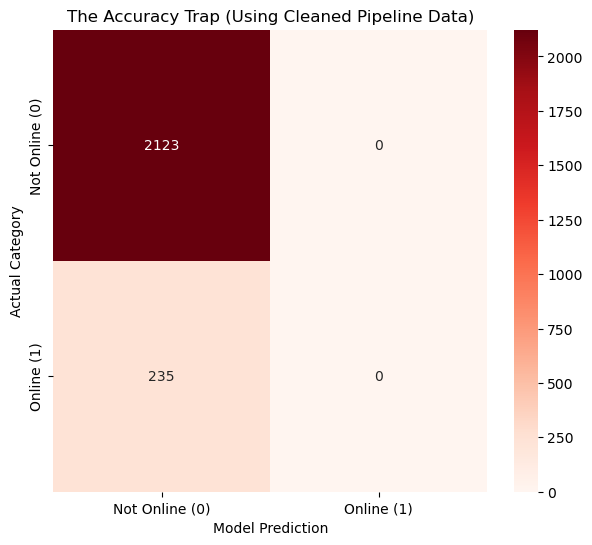

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load the cleaned dataset (the output from Phase 1)
# This maintains the "Traceable data bridge" requirement
df = pd.read_csv('cleaned_shopping_data.csv')

# 2. Define Features and Target (already cleaned/engineered in previous step)
features = ['monthly_income', 'daily_internet_hours', 'tech_savvy_score']
X = df[features]
y = df['Is_Online']

# 3. Train-Test Split (80% Train, 20% Test)
# stratify=y is critical to maintain the 10/90 class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Baseline Modeling: Training on imbalanced cleaned data
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Evaluate the "Accuracy Trap"
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy on Cleaned Data: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. Generate Plot to visualize the failure
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Not Online (0)', 'Online (1)'], 
            yticklabels=['Not Online (0)', 'Online (1)'])
plt.title('The Accuracy Trap (Using Cleaned Pipeline Data)')
plt.ylabel('Actual Category')
plt.xlabel('Model Prediction')
plt.savefig('accuracy_trap_cleaned.png')

### Advanced Reasoning 2

Having an accuracy score of 90% but a recall of 0 is a silent failure because it means that the model is accurately predicting 90% of the time, however it is completely missing the minority class meaning it is preciting everyone is a in store shopper and missing all the online shoppers. The data is imbalanced so the model is guessing instead of making actual predictions. This misleads stakeholders, because it appears as though it has a high success rate, but it is predicting 0 out of 10 shoppers as online and can still have a high accuracy.

### Strategic Trade-off

In this case you should prioritize recall over accuracy. This is because if an online shopper is missed, the company will lose the opportunity to convert them with a digital ad or a personalized discount. Additionally, if they send an "Online-only" discount to someone who prefers the physical store, the cost is the fraction of a cent it takes to send an automated email. It is better for companies send 1000 people emails to people who might not buy online, than miss 100 people who would make online purchases. 

## Part Three: SQL-Integrated Error Analysis

In [7]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# 1. Load the cleaned data (to map back to IDs)
df = pd.read_csv('cleaned_shopping_data.csv')
# Create a Customer_ID if one doesn't exist to match our SQL schema
df['Customer_ID'] = df.index + 1

# 2. Re-run model to get test predictions (using the 80/20 split from Part 2)
# ... [Model training logic as before] ...
y_pred = model.predict(X_test)

# 3. Create the Audit DataFrame
df_audit = pd.DataFrame({
    'Customer_ID': df.loc[X_test.index, 'Customer_ID'],
    'Actual': y_test,
    'Predicted': y_pred
})

# 4. Export to SQL (or CSV for Import Wizard)
df_audit.to_csv('model_audit.csv', index=False)

# Python SQL Alchemy connection (Update credentials as needed)
params = urllib.parse.quote_plus(r'DRIVER={ODBC Driver 17 for SQL Server};SERVER=Kelsey;DATABASE=Lab_5_&_6;Trusted_Connection=yes;')
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
df_audit.to_sql('Model_Audit', con=engine, if_exists='replace', index=False)

c:\Users\kelse\miniforge3\envs\ml-env\Lib\site-packages\pandas\io\sql.py:1649: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


261

### Advanced Reasoning 3

Persistent failures in Tier 3 show that the current features are under-specified and missing the local context that actually drives behavior. The model is blind to the physical reality of these cities because digital proxies, like internet hours, break down when things like logistics gaps or delivery fees become the real deal-breakers. The geography acts as a filter that changes how tech-savviness translates into online shopping depending on the local infrastructure.

## Part Four: 2026 Market & Ethics

### GenAI Perspective

Consistency is evaluated through "Persona Testing" by feeding the LLM identical profiles where only age is modified to observe if recommendations or tone shift unfairly. Variance in discount values and product relevance scores across different age brackets serves as the primary metric to ensure the AI isn't defaulting to generational stereotypes.

### Fairness Audit

Fixing gender bias without deleting the column involves implementing equalized odds by adjusting classification thresholds independently for each group to balance error rates. Adversarial Debiasing can also be utilized, where a secondary model is trained to strip gendered patterns from the primary model's decision-making process.

### Go/No-Go Decision

This is a No-Go because the model has zero recall for online shoppers, meaning it fails to identify the specific customers it was built to target. The systematic risk is market exclusion, where a biased feedback loop ignores Tier 3 digital growth and hands that entire market share to competitors.